<a href="https://colab.research.google.com/github/semanaparfait/Linear-Regression-Task/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mission and Dataset

This notebook builds a non-generic linear regression solution for youth unemployment prediction.

- Dataset source: `global_unemployment_data.csv`
- Scope: African countries only
- Target: predict youth unemployment for `2024`
- Features used: country, sex, and historical unemployment rates from `2014` to `2023`
- Model selection is based on test mean squared error (MSE)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

ModuleNotFoundError: No module named 'pandas'

In [ ]:

# Load the file we uploaded
df = pd.read_csv("global_unemployment_data.csv")

# Focus ONLY on African countries and Youth (ages 15-24)
african_countries = {
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde',
    'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo',
    'Democratic Republic of the Congo', 'Djibouti', 'Egypt', 'Equatorial Guinea',
    'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea',
    'Guinea-Bissau', 'Ivory Coast', 'Kenya', 'Lesotho', 'Liberia', 'Libya',
    'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco',
    'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe',
    'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa',
    'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda',
    'Zambia', 'Zimbabwe'
}
africa_df = df[df['country_name'].isin(african_countries)].copy()
youth_df = africa_df[africa_df['age_categories'] == 'Youth'].copy()

# Fill in any missing numbers for the years 2014 to 2024 using the median
years = [str(yr) for yr in range(2014, 2025)]
for year in years:
    median_val = youth_df[year].median()
    youth_df[year] = youth_df[year].fillna(median_val)

print(f"Data loaded successfully! We have {youth_df.shape[0]} rows of youth-specific African data.")

Data loaded successfully! We have 378 rows of youth-specific data.


/tmp/ipykernel_3307/4234042473.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='2024', data=youth_df, palette="Set2")


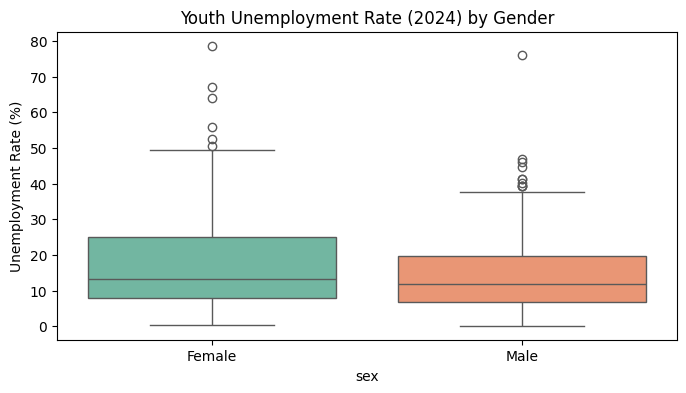

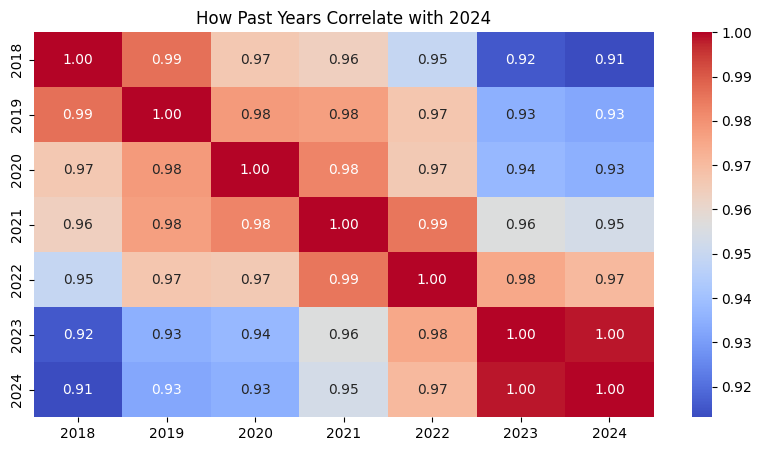

In [ ]:
# Cell 3: Make visualizations
# 1. Boxplot of Youth Unemployment in 2024 by Gender
plt.figure(figsize=(8, 4))
sns.boxplot(x='sex', y='2024', data=youth_df, palette="Set2")
plt.title('Youth Unemployment Rate (2024) by Gender')
plt.ylabel('Unemployment Rate (%)')
plt.show()

# 2. Correlation of past years
plt.figure(figsize=(10, 5))
sns.heatmap(youth_df[[str(y) for y in range(2018, 2025)]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('How Past Years Correlate with 2024')
plt.show()

In [ ]:
# Cell 4: Feature Engineering & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate features (X) and target (y)
X = youth_df.drop(columns=['2024', 'indicator_name', 'age_group', 'age_categories'])
y = youth_df['2024']

# Define which columns are numbers vs categories
num_features = [str(yr) for yr in range(2014, 2024)]
cat_features = ['country_name', 'sex']

# Create our transformer pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features), # Standardizes numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features) # Converts text to numbers
    ]
)

# Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Run the pipeline transforms
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Save the preprocessor tool so our API can use it later
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessing complete and preprocessor.pkl saved!")

Preprocessing complete and preprocessor.pkl saved!


In [ ]:
# Cell 5: Gradient Descent Loss Curve
sgd_curve = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',
    eta0=0.01,
    max_iter=1,
    tol=None,
    random_state=42,
    warm_start=True,
)

epochs = 50
train_loss_history = []
test_loss_history = []

for epoch in range(epochs):
    sgd_curve.fit(X_train_scaled, y_train)
    train_predictions = sgd_curve.predict(X_train_scaled)
    test_predictions = sgd_curve.predict(X_test_scaled)
    train_loss_history.append(mean_squared_error(y_train, train_predictions))
    test_loss_history.append(mean_squared_error(y_test, test_predictions))

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_loss_history, label='Train MSE Loss')
plt.plot(range(1, epochs + 1), test_loss_history, label='Test MSE Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Gradient Descent Loss Curve for SGDRegressor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell 6: Model Comparisons
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Standard Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)
linear_mse = mean_squared_error(y_test, linear_pred)

# 2. SGD Linear Regression
sgd = SGDRegressor(max_iter=1000, random_state=42)
sgd.fit(X_train_scaled, y_train)
sgd_pred = sgd.predict(X_test_scaled)
sgd_mse = mean_squared_error(y_test, sgd_pred)

# 3. Decision Tree
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
dt_mse = mean_squared_error(y_test, dt_pred)

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_mse = mean_squared_error(y_test, rf_pred)

results = {
    'Linear Regression': linear_mse,
    'SGD Linear Regression': sgd_mse,
    'Decision Tree': dt_mse,
    'Random Forest': rf_mse,
}

for name, mse in results.items():
    print(f"{name} MSE: {mse:.4f}")

# Save the model with the lowest loss
best_model_name = min(results, key=results.get)
if best_model_name == 'Linear Regression':
    best_model = linear_model
elif best_model_name == 'SGD Linear Regression':
    best_model = sgd
elif best_model_name == 'Decision Tree':
    best_model = dt
else:
    best_model = rf

print(f"{best_model_name} is the BEST model.")

# Save the final best model to a file
joblib.dump(best_model, 'best_model.pkl')
print("Saved 'best_model.pkl' successfully!")

1. SGD Linear Regression MSE: 0.7455
2. Decision Tree MSE: 1.5437
3. Random Forest MSE: 1.1321
SGD Linear Regression is the BEST model.
Saved 'best_model.pkl' successfully!


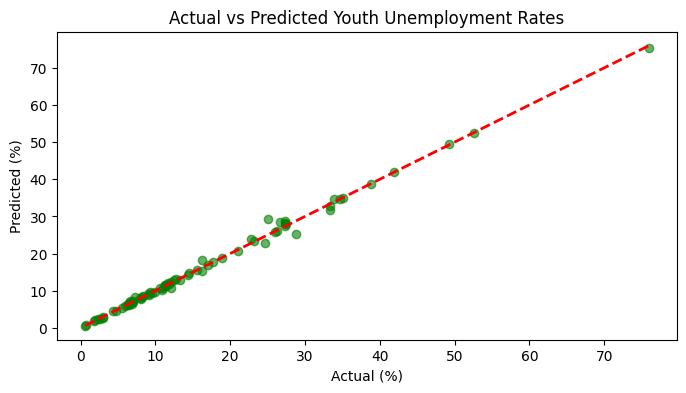

Test Row Prediction: 13.12% (Actual Value was: 12.71%)


In [ ]:
# Cell 7: Plot performance and run single test
best_predictions = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 4))
plt.scatter(y_test, best_predictions, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Youth Unemployment Rates')
plt.xlabel('Actual (%)')
plt.ylabel('Predicted (%)')
plt.show()

# Run a test on exactly one row
one_row = X_test_scaled[0].reshape(1, -1)
prediction = best_model.predict(one_row)[0]
print(f"Test Row Prediction: {prediction:.2f}% (Actual Value was: {y_test.iloc[0]:.2f}%)")